In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import json

In [2]:
pred = pd.read_csv("/dccstor/ipc1/CAR/DREAM/Model/Test/After_synthetic/HCC70/valid_output_states.csv", index_col=0)
true = pd.read_csv("/dccstor/ipc1/CAR/DREAM/Model/Test/After_synthetic/HCC70/valid_data.csv", index_col=0).reset_index(drop=True)

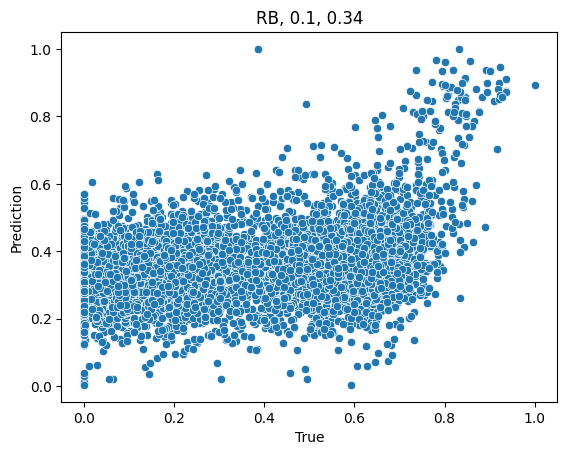

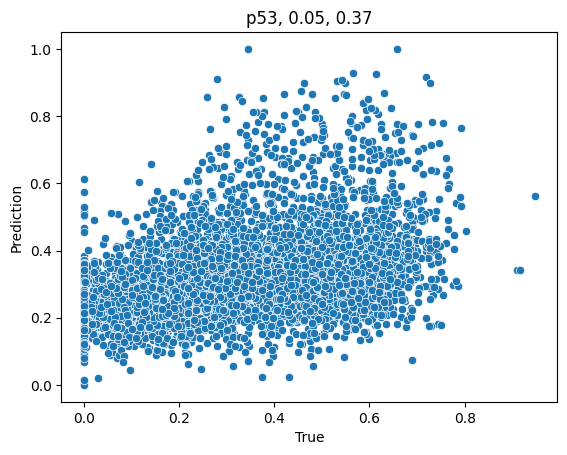

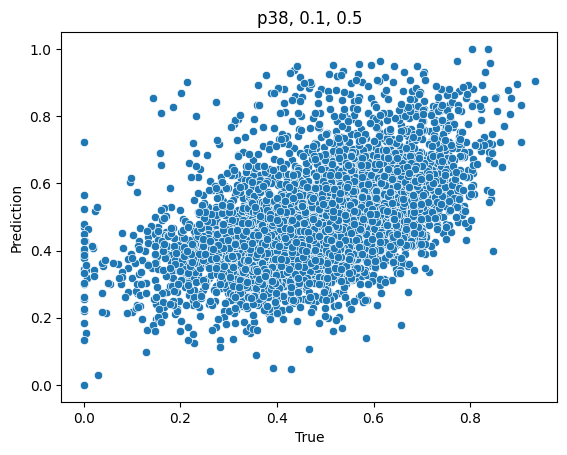

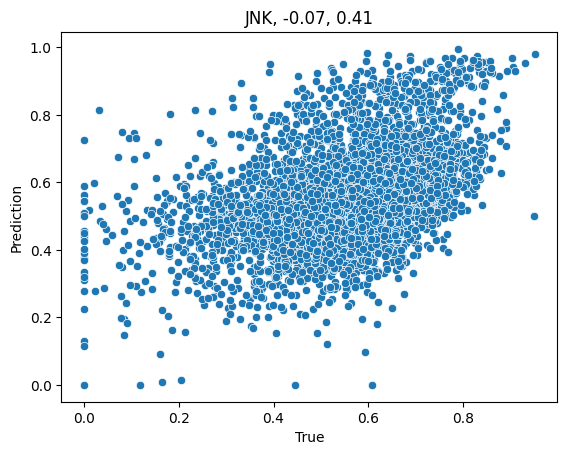

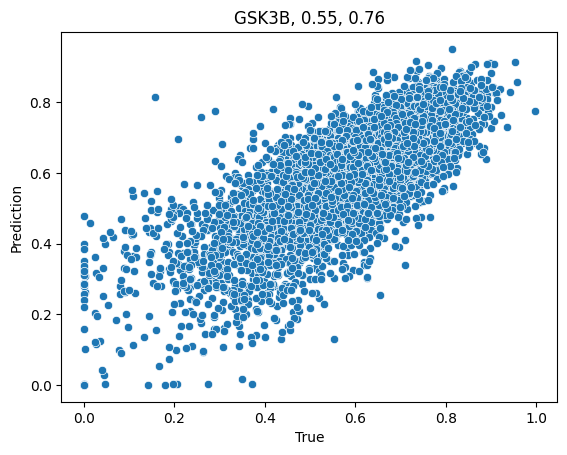

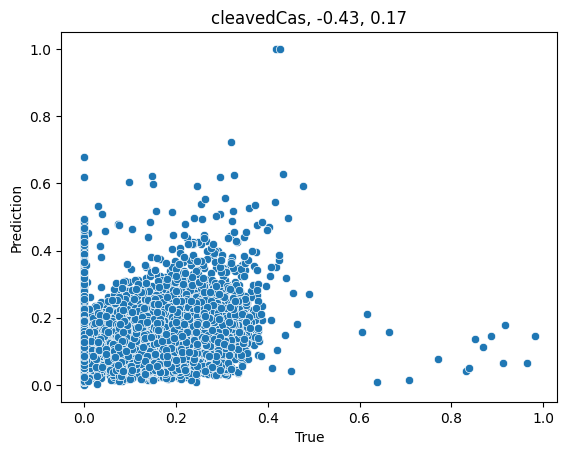

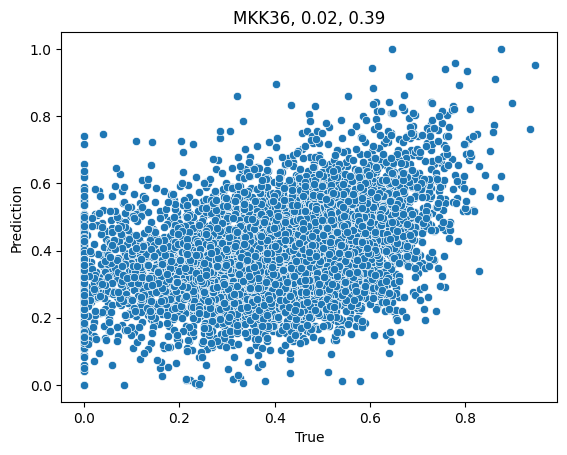

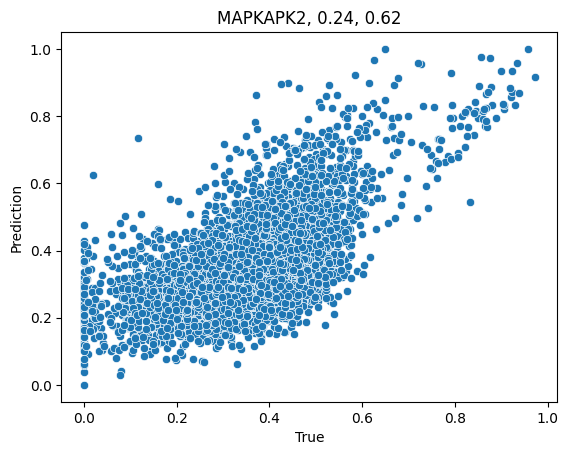

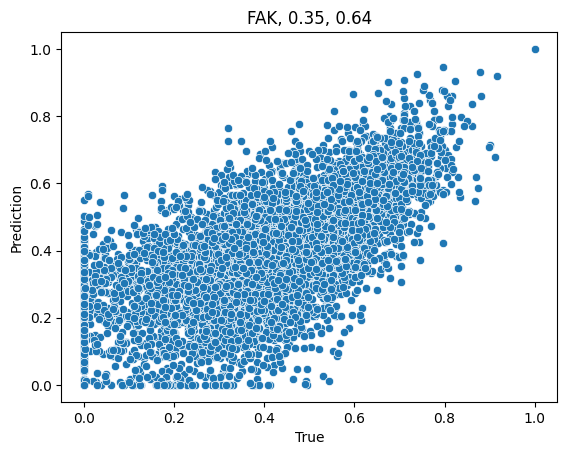

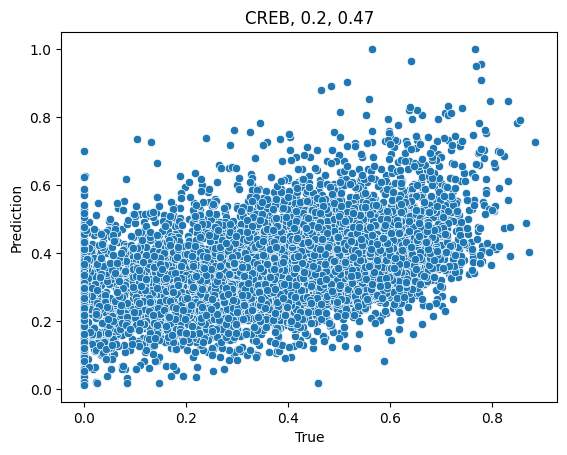

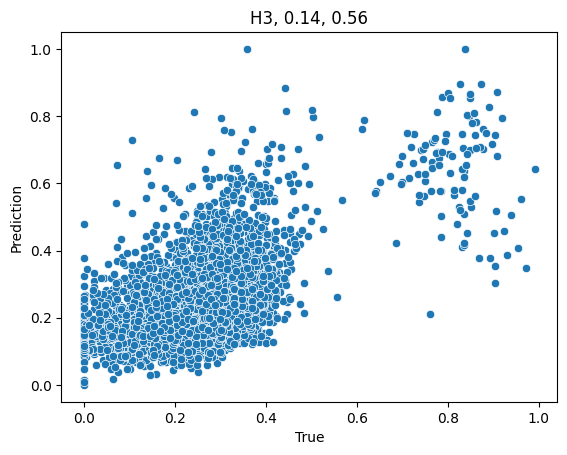

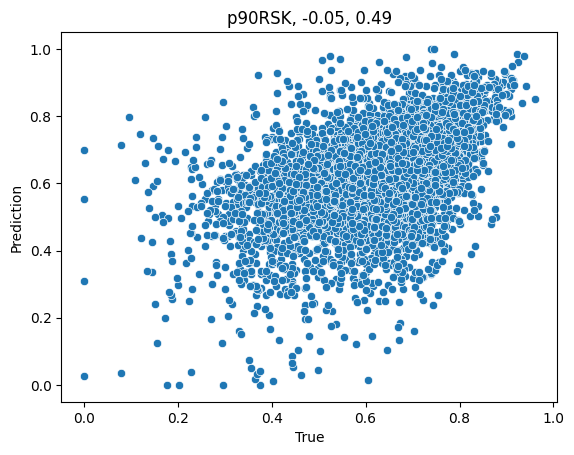

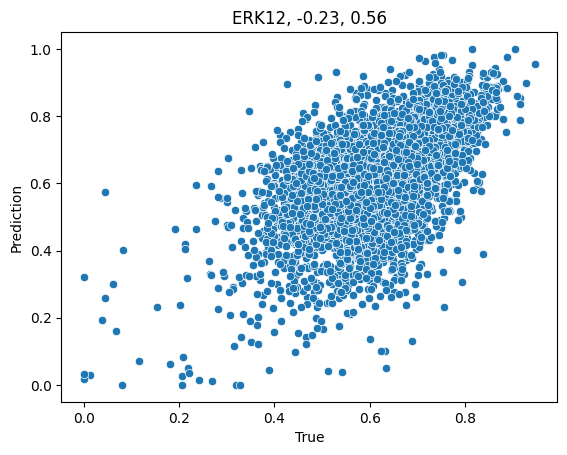

In [3]:
markers = set(pred.columns).intersection(set(true.columns))
eval_markers = ["RB", "p53", "p38", "JNK", "GSK3B", "cleavedCas", "MKK36", "MAPKAPK2", 
                "FAK", "CREB", "H3", "p90RSK", "ERK12"]
r2_scores = []
correlations = []
for marker in eval_markers:
    corr = true[marker].corr(pred[marker], method='pearson')
    correlations.append(corr)
    r2 = r2_score(true[marker], pred[marker])
    r2_scores.append(r2)
    sns.scatterplot(x=true[marker], y=pred[marker])
    plt.xlabel("True")
    plt.ylabel("Prediction")
    plt.title(f"{marker}, {round(r2, 2)}, {round(corr, 2)}")
    plt.show()

In [4]:
pd.Series(r2_scores).mean()

0.07472979507564145

In [5]:
pd.Series(correlations).mean()

0.4825384797593787

In [6]:
true[eval_markers].max()

RB            1.000000
p53           0.947275
p38           0.933701
JNK           0.950660
GSK3B         0.996852
cleavedCas    0.981319
MKK36         0.945256
MAPKAPK2      0.971840
FAK           1.000000
CREB          0.884125
H3            0.991347
p90RSK        0.960193
ERK12         0.946427
dtype: float64

In [7]:
pred.max()

p53           1.000000
RB            1.000000
GSK3B         0.950378
AMPK          0.994578
cleavedCas    1.000000
SMAD23        0.924617
ERK12         1.000000
MSK12         1.000000
MKK36         1.000000
H3            1.000000
p90RSK        1.000000
p38           1.000000
MAPKAPK2      1.000000
CREB          1.000000
AKT_S473      0.953457
AKT           0.950014
AKT_T308      0.995201
SRC           1.000000
FAK           1.000000
MKK4          0.979947
JNK           0.995771
MEK12         1.000000
dtype: float64

In [8]:
true[eval_markers].min()

RB            0.0
p53           0.0
p38           0.0
JNK           0.0
GSK3B         0.0
cleavedCas    0.0
MKK36         0.0
MAPKAPK2      0.0
FAK           0.0
CREB          0.0
H3            0.0
p90RSK        0.0
ERK12         0.0
dtype: float64

In [9]:
pred.min()

p53           4.789716e-10
RB            3.463046e-03
GSK3B         8.893274e-10
AMPK          1.000000e-09
cleavedCas    1.706736e-10
SMAD23        1.000000e-09
ERK12         1.209037e-09
MSK12         4.837759e-10
MKK36         4.688718e-10
H3            3.224199e-10
p90RSK        1.252741e-09
p38           1.000362e-09
MAPKAPK2      4.767617e-10
CREB          1.226725e-02
AKT_S473      1.000000e-09
AKT           8.904705e-10
AKT_T308      1.000000e-09
SRC           1.000000e-09
FAK           7.357852e-10
MKK4          1.000000e-09
JNK           1.398078e-09
MEK12         1.000000e-09
dtype: float64

In [10]:
losses = pd.read_csv("/dccstor/ipc1/CAR/DREAM/Model/Test/After_synthetic/HCC70/loss.csv", index_col=0)
losses = losses.reset_index()
losses = losses.drop("time", axis=1)

<AxesSubplot:xlabel='index', ylabel='loss'>

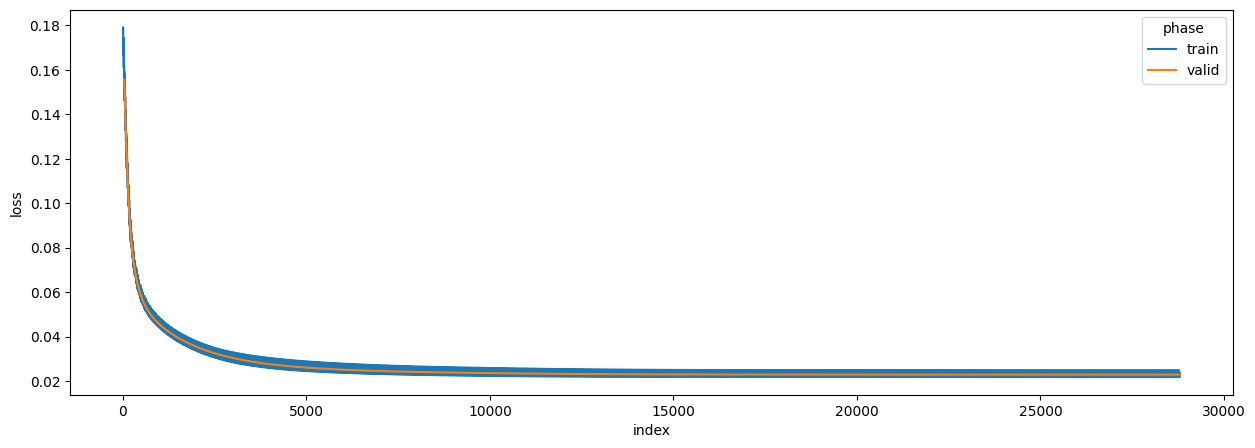

In [11]:
plt.figure(figsize=(15,5))
sns.lineplot(data=losses, x="index", y="loss", hue="phase")
